# EPS 109 "Computer Simulations in Earth and Planetary Science"
### Instructor: Burkhard Militzer
### Combined lab and homework assignment on sound and audio files: Part 5


You may not have been aware of this but Salma is in fact a rock musician. She recorded something super simple for us. So from bCourses, please download her file: "Salmas_recording.wav" and apply to it the following steps from part4: 

(1) Listen to the recording and plot the sound amplitude as function of time:

Data rate [units of Hz = 1/seconds] =  48000
Array: data
shape: (604160,)
dtype: int16
min, max: -8502 9955



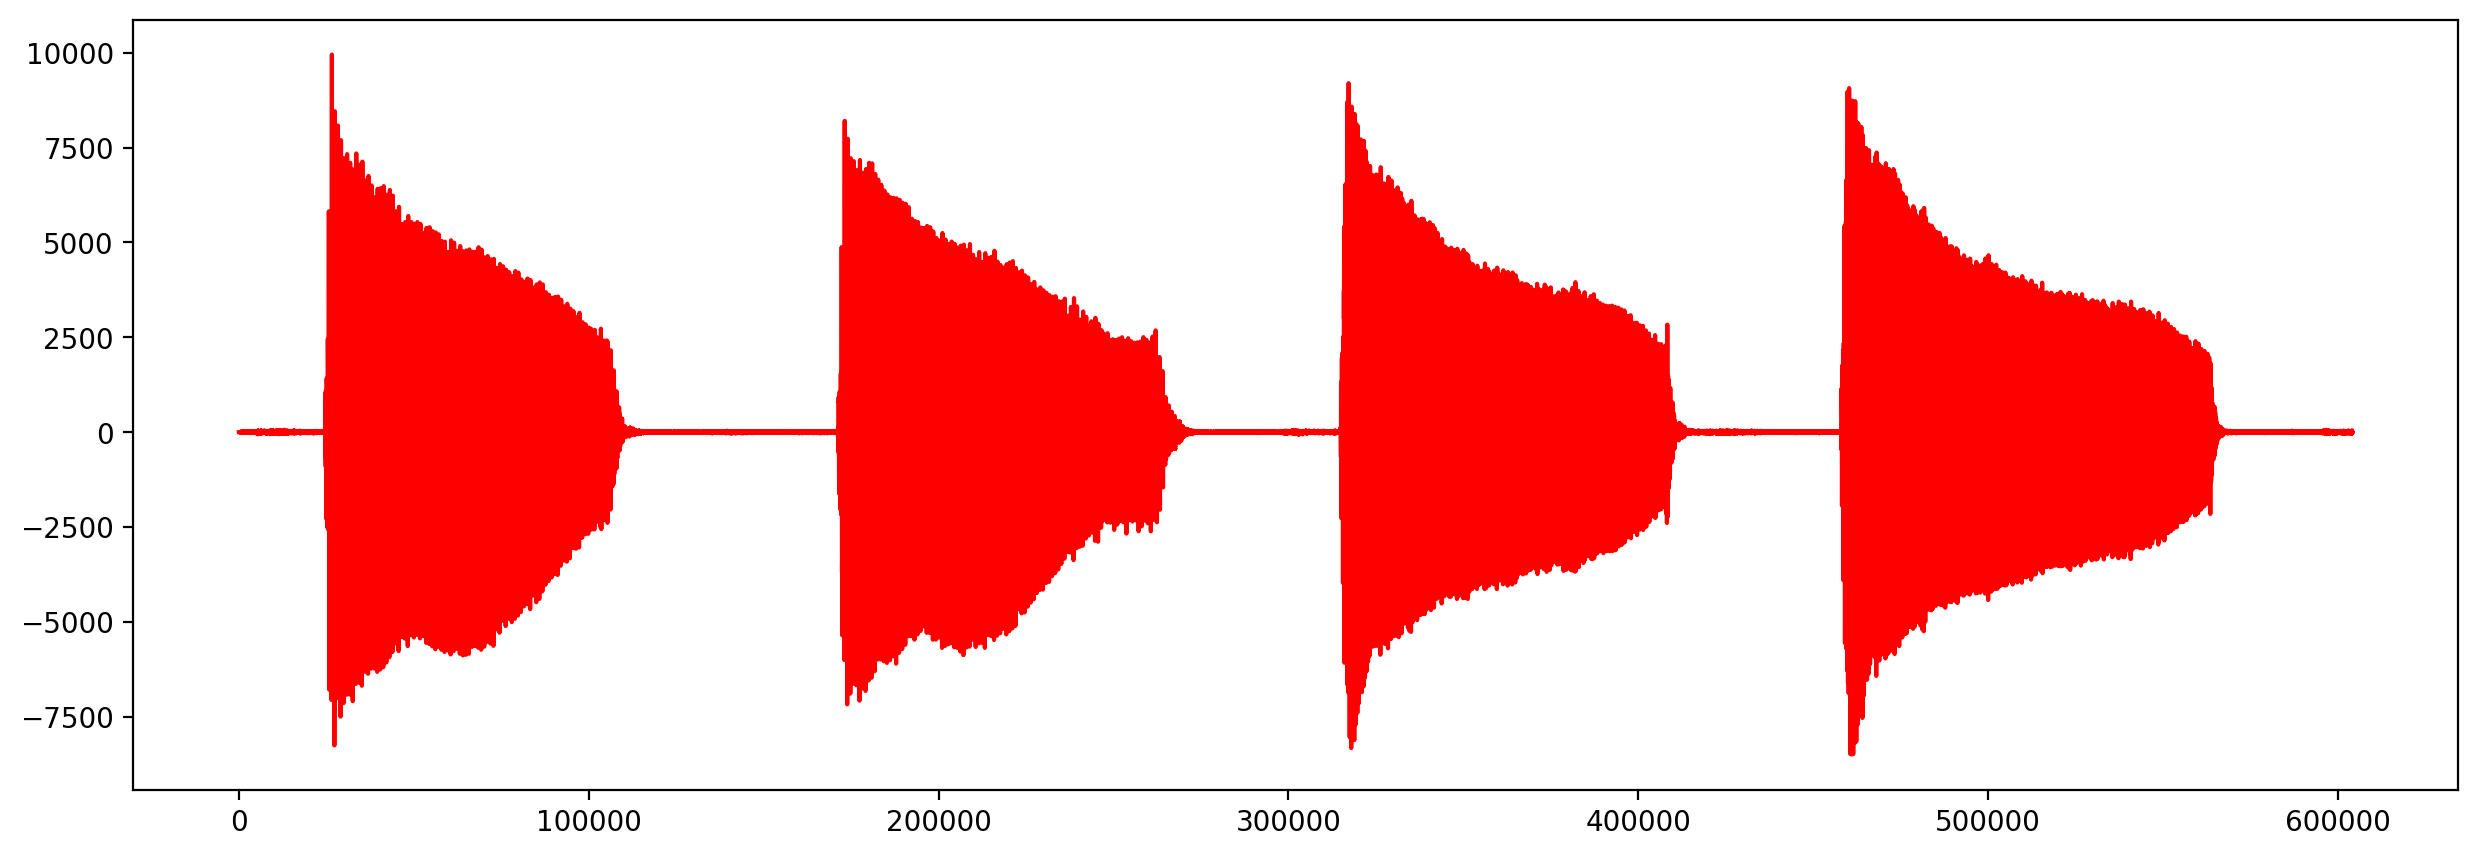

In [3]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import numpy as np
import simpleaudio as sa
from scipy.io import wavfile

def PrintArrayInfo(a,name=''):
    if (len(name)==0):
        print("Array info:")
    else:
        print("Array:", name)
    print("shape:", a.shape)
    print("dtype:", a.dtype)
    print("min, max:", a.min(), a.max())
    print()

filename = 'Salmas_recording.wav'
wave_obj = sa.WaveObject.from_wave_file(filename)
#play_obj = wave_obj.play()
#play_obj.wait_done()  # Wait until sound has finished playing

rate, data = wavfile.read(filename)
print("Data rate [units of Hz = 1/seconds] = ",rate)
PrintArrayInfo(data,"data")

plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data,'r-')
plt.show()

(2) Fourier transform the entire recording starting with a frequency in of 80 and ending with 5000. Then plot the Fourier transform as function of frequency index. You should see that three, maybe four, frequencies stand out. 

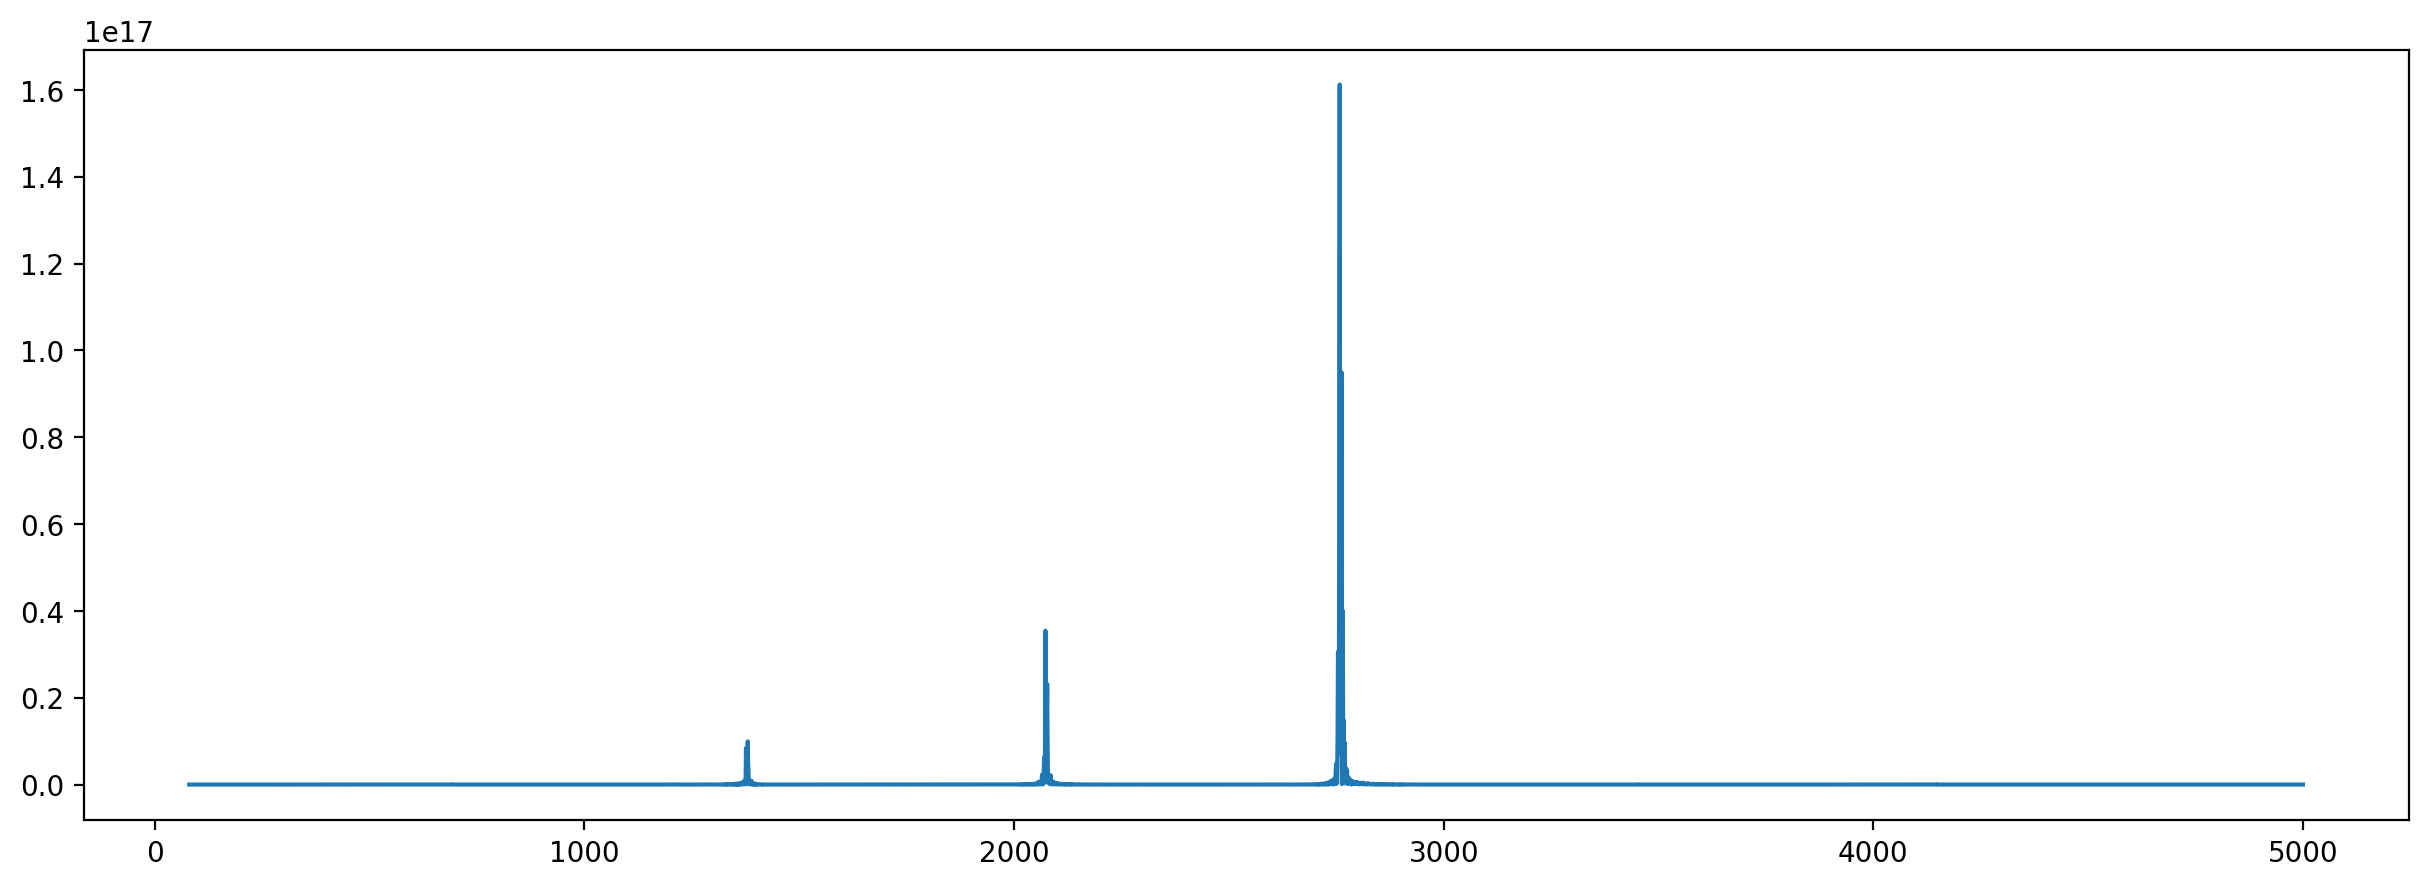

In [5]:
def fourier(x,k):
    n = len(x)
    j = np.arange(0,n)

    f_sin = np.sum(x * np.sin(2 * np.pi * j * k/n))
    f_cos = np.sum(x * np.cos(2 * np.pi * j * k/n))

    return f_sin**2 + f_cos**2

k1 = 80
k2 = 5000
frequency_indices = np.arange(80,5001)
frequency_indices_results = np.array([fourier(data,k) for k in frequency_indices])
plt.plot(frequency_indices,frequency_indices_results)

(3) Convert the frequencies indices 'k' for regular frequencies in units of Hertz (oscillations per second). Repeat the plot from part (2) with frequency as X axis.

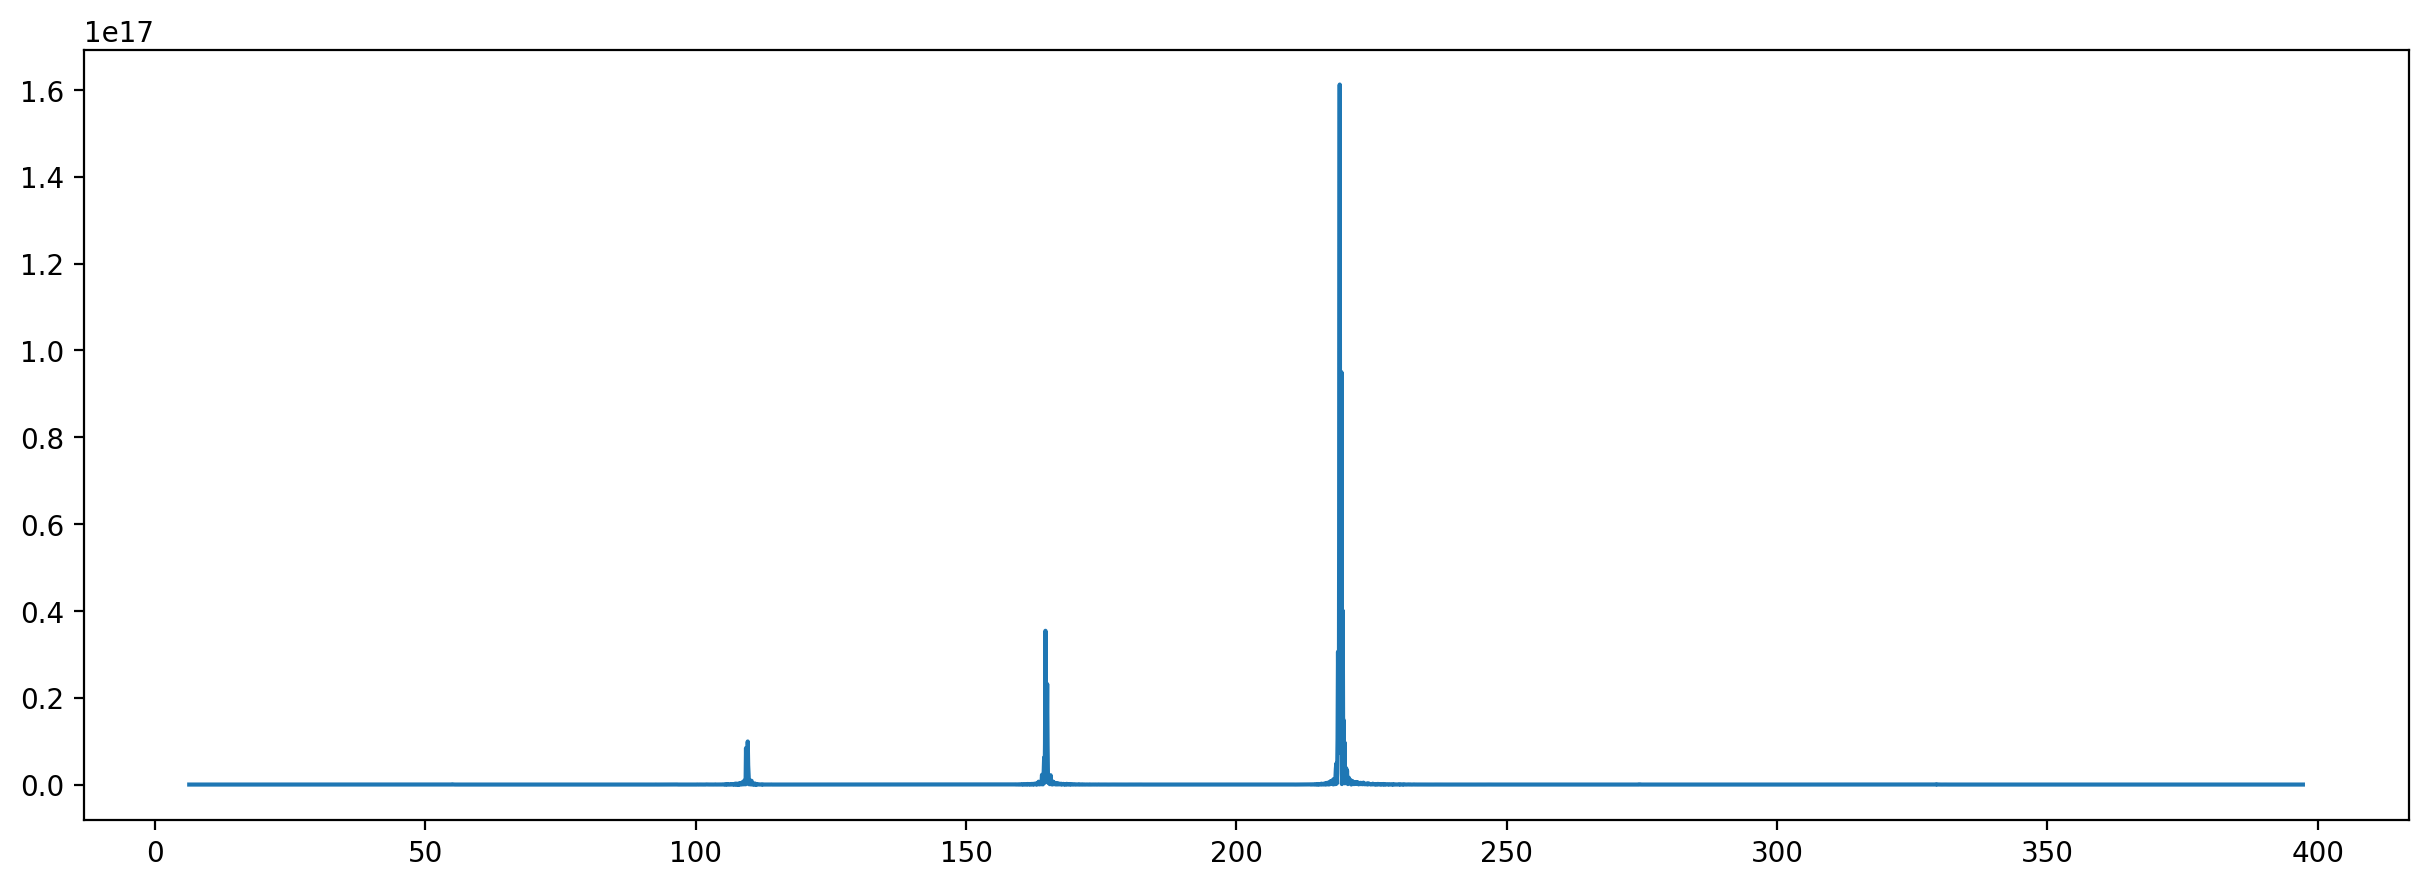

In [6]:
k1 = 80
k2 = 5000
frequency_indices = np.arange(80,5001)
frequency_hz = frequency_indices*(rate/len(data))
frequency_indices_results_hz = np.array([fourier(data,k) for k in frequency_indices])
plt.plot(frequency_hz,frequency_indices_results_hz)

(4) In order of decreasing amplidude, list the frequencies in Hertz of the three dominant waves. Speculate which note Salma was playing for us and offer an explanation for why we don't just hear a single frequency.

In [11]:
highest_peak = (frequency_hz >=200) & (frequency_hz <= 250)
highest_peak_indice_local = np.argmax(frequency_indices_results_hz[highest_peak])
global_indices_highest = np.where(highest_peak)[0]
highest_peak_indice_global = global_indices_highest[highest_peak_indice_local]

middle_peak = (frequency_hz >= 150) & (frequency_hz <= 190)
middle_peak_indice_local = np.argmax(frequency_indices_results_hz[middle_peak])
global_indices_middle = np.where(middle_peak)[0]
middle_peak_indice_global = global_indices_middle[middle_peak_indice_local]

lowest_peak = (frequency_hz >=100) & (frequency_hz <= 145)
lowest_peak_indice_local = np.argmax(frequency_indices_results_hz[lowest_peak])
global_indices_lowest = np.where(lowest_peak)[0]
lowest_peak_indice_global = global_indices_lowest[lowest_peak_indice_local]

highest_peak_frequency = frequency_hz[highest_peak_indice_global]
middle_peak_frequency = frequency_hz[middle_peak_indice_global]
lowest_peak_frequency = frequency_hz[lowest_peak_indice_global]
print(highest_peak_frequency,middle_peak_frequency,lowest_peak_frequency)

219.1207627118644 164.698093220339 109.63983050847457


In [12]:
#The frequencies of the three dominant waves are 219.12 hz, 164.70 hz, and 109.64 hz
#I suspect Salma is playing an A3
#I think we don't hear just a single frequency because the sound can bounce of the instrument or other objects